# Taller 3 - Deteccion de Fachadas y Postes + Inpainting

## Objetivos
1. Fine-tuning de YOLOv8 con 2 clases: casa y poste
2. Evaluacion del modelo (mAP, Precision, Recall)
3. Generacion de mascaras binarias de postes detectados
4. Pipeline listo para eliminar postes con Inpainting (LaMa o Inpaint-Anything)

## Estructura esperada del dataset
El dataset debe estar en la misma carpeta que este notebook dentro de Google Drive:

    <carpeta del notebook>/     <- DRIVE_ROOT (detectado automaticamente)
      Taller_3.ipynb
      dataset_roboflow_t3/
        casas.yolov8/
          train/images/  train/labels/
          valid/images/  valid/labels/
          test/images/   test/labels/
          data.yaml

> Antes de ejecutar: sube dataset_roboflow_t3 a la misma carpeta del notebook en Drive.

In [1]:
try:
    !fusermount -u /content/drive
except OSError as e:
    print(f"Warning: Could not unmount /content/drive. It might not be mounted or busy. Error: {e}")

# Remove any remaining files in the mount point if not unmounted properly
import os
if os.path.exists('/content/drive') and os.path.ismount('/content/drive'):
    # If still mounted, force unmount might be needed or manual intervention
    pass # Will try to mount again, which might fail or succeed depending on underlying issue
elif os.path.exists('/content/drive') and os.listdir('/content/drive'):
    # If not mounted but contains files, clear it
    print("Cleaning up /content/drive directory...")
    !rm -rf /content/drive/*

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 0. Configuracion de rutas y parametros globales

In [20]:
import os

DRIVE_ROOT = '/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2'
DATASET_FOLDER = 'dataset_roboflow_t3/casas.yolov8'
DATASET_PATH   = os.path.join(DRIVE_ROOT, DATASET_FOLDER)
DATA_YAML      = os.path.join(DATASET_PATH, 'data.yaml')

CLASSES        = ['casa', 'poste']
CLASS_POSTE_ID = 1

BASE_MODEL  = 'yolov8n.pt'

EPOCHS      = 50
IMG_SIZE    = 640
BATCH_SIZE  = 16

PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2'
RUN_NAME    = 'casas_postes_v1'
MASKS_DIR   = '/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/mascaras_postes'
os.makedirs(MASKS_DIR, exist_ok=True)

print('Rutas configuradas:')
print(f'  DRIVE_ROOT : {DRIVE_ROOT}')
print(f'  Dataset    : {DATASET_PATH}')
print(f'  data.yaml  : {DATA_YAML}')
print(f'  Proyecto   : {PROJECT_DIR}/{RUN_NAME}')
print(f'  Mascaras   : {MASKS_DIR}')

Rutas configuradas:
  DRIVE_ROOT : /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2
  Dataset    : /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8
  data.yaml  : /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/data.yaml
  Proyecto   : /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/casas_postes_v1
  Mascaras   : /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/mascaras_postes


---
## 1. Verificar GPU

In [3]:
!nvidia-smi

Sun Mar 22 15:59:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## 2. Instalar dependencias

In [4]:
!pip install -q ultralytics opencv-python-headless matplotlib pillow pyyaml

from ultralytics import YOLO
import ultralytics
print('Ultralytics version:', ultralytics.__version__)

Ultralytics version: 8.4.24


---
## 3. Montar Google Drive y verificar dataset

In [5]:
import os

assert os.path.exists(DATASET_PATH), (
    f'No se encontro el dataset en: {DATASET_PATH}\n'
    'Sube dataset_roboflow_t3 a la carpeta del notebook en Drive.')
assert os.path.exists(DATA_YAML), (
    f'No se encontro data.yaml en: {DATA_YAML}')

for split in ['train', 'valid', 'test']:
    p = os.path.join(DATASET_PATH, split, 'images')
    n = len(os.listdir(p)) if os.path.exists(p) else 0
    print(f'  {split}/images: {n} imagenes')

print('\n--- data.yaml original ---')
with open(DATA_YAML) as f:
    print(f.read())

  train/images: 134 imagenes
  valid/images: 31 imagenes
  test/images: 19 imagenes

--- data.yaml original ---
names:
- casa
- poste
nc: 2
roboflow:
  license: Private
  project: my-first-project-uaprr
  url: https://app.roboflow.com/pepitos-workspace/my-first-project-uaprr/4
  version: 4
  workspace: pepitos-workspace
test: /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/test/images
train: /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/train/images
val: /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/valid/images



In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 4. Preparar data.yaml con rutas absolutas

Roboflow puede exportar rutas relativas; esta celda las convierte a absolutas.

In [7]:
import yaml

with open(DATA_YAML, 'r') as f:
    cfg = yaml.safe_load(f)

cfg['train'] = os.path.join(DATASET_PATH, 'train', 'images')
cfg['val']   = os.path.join(DATASET_PATH, 'valid', 'images')
cfg['test']  = os.path.join(DATASET_PATH, 'test',  'images')
cfg['nc']    = len(CLASSES)
cfg['names'] = CLASSES

with open(DATA_YAML, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)

print('data.yaml actualizado:')
with open(DATA_YAML) as f:
    print(f.read())

data.yaml actualizado:
names:
- casa
- poste
nc: 2
roboflow:
  license: Private
  project: my-first-project-uaprr
  url: https://app.roboflow.com/pepitos-workspace/my-first-project-uaprr/4
  version: 4
  workspace: pepitos-workspace
test: /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/test/images
train: /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/train/images
val: /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/valid/images



---
## 5. Fine-tuning de YOLOv8

In [8]:
from ultralytics import YOLO

model = YOLO(BASE_MODEL)
print(f'Modelo base: {BASE_MODEL}')

results = model.train(
    data     = DATA_YAML,
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH_SIZE,
    project  = PROJECT_DIR,
    name     = RUN_NAME,
    device   = 0,
    exist_ok = True,
    plots    = True,
)

BEST_MODEL_PATH = os.path.join(PROJECT_DIR, RUN_NAME, 'weights', 'best.pt')
print('\nEntrenamiento completado.')
print(f'Mejor modelo: {BEST_MODEL_PATH}')

Modelo base: yolov8n.pt
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=casas_postes_v1, n

---
## 6. Visualizar curvas de entrenamiento

--- results.png ---


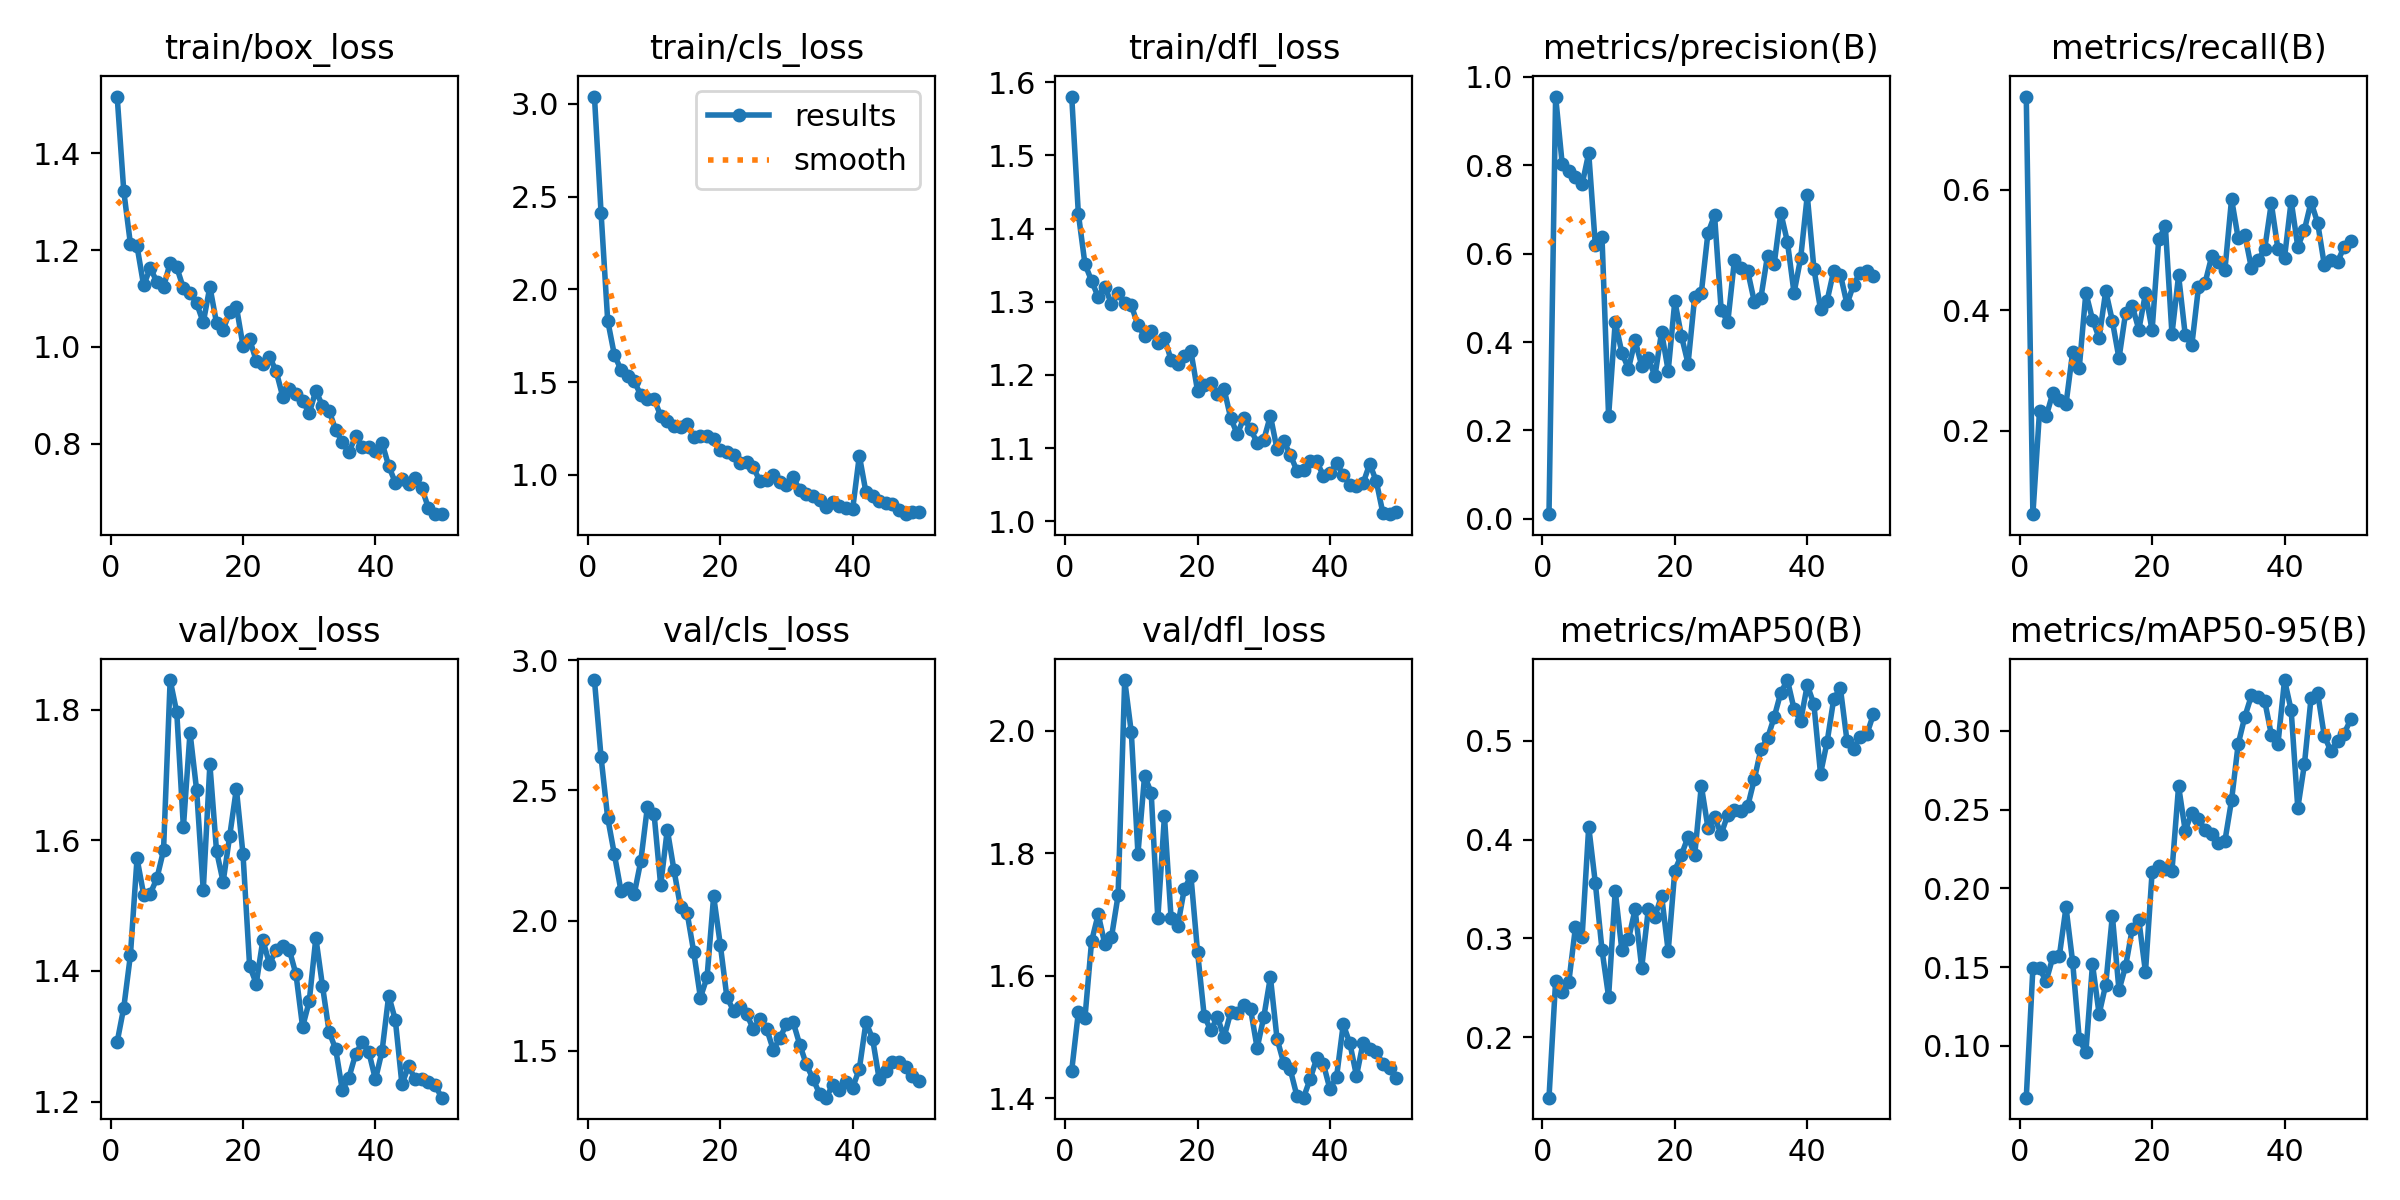

--- confusion_matrix.png ---


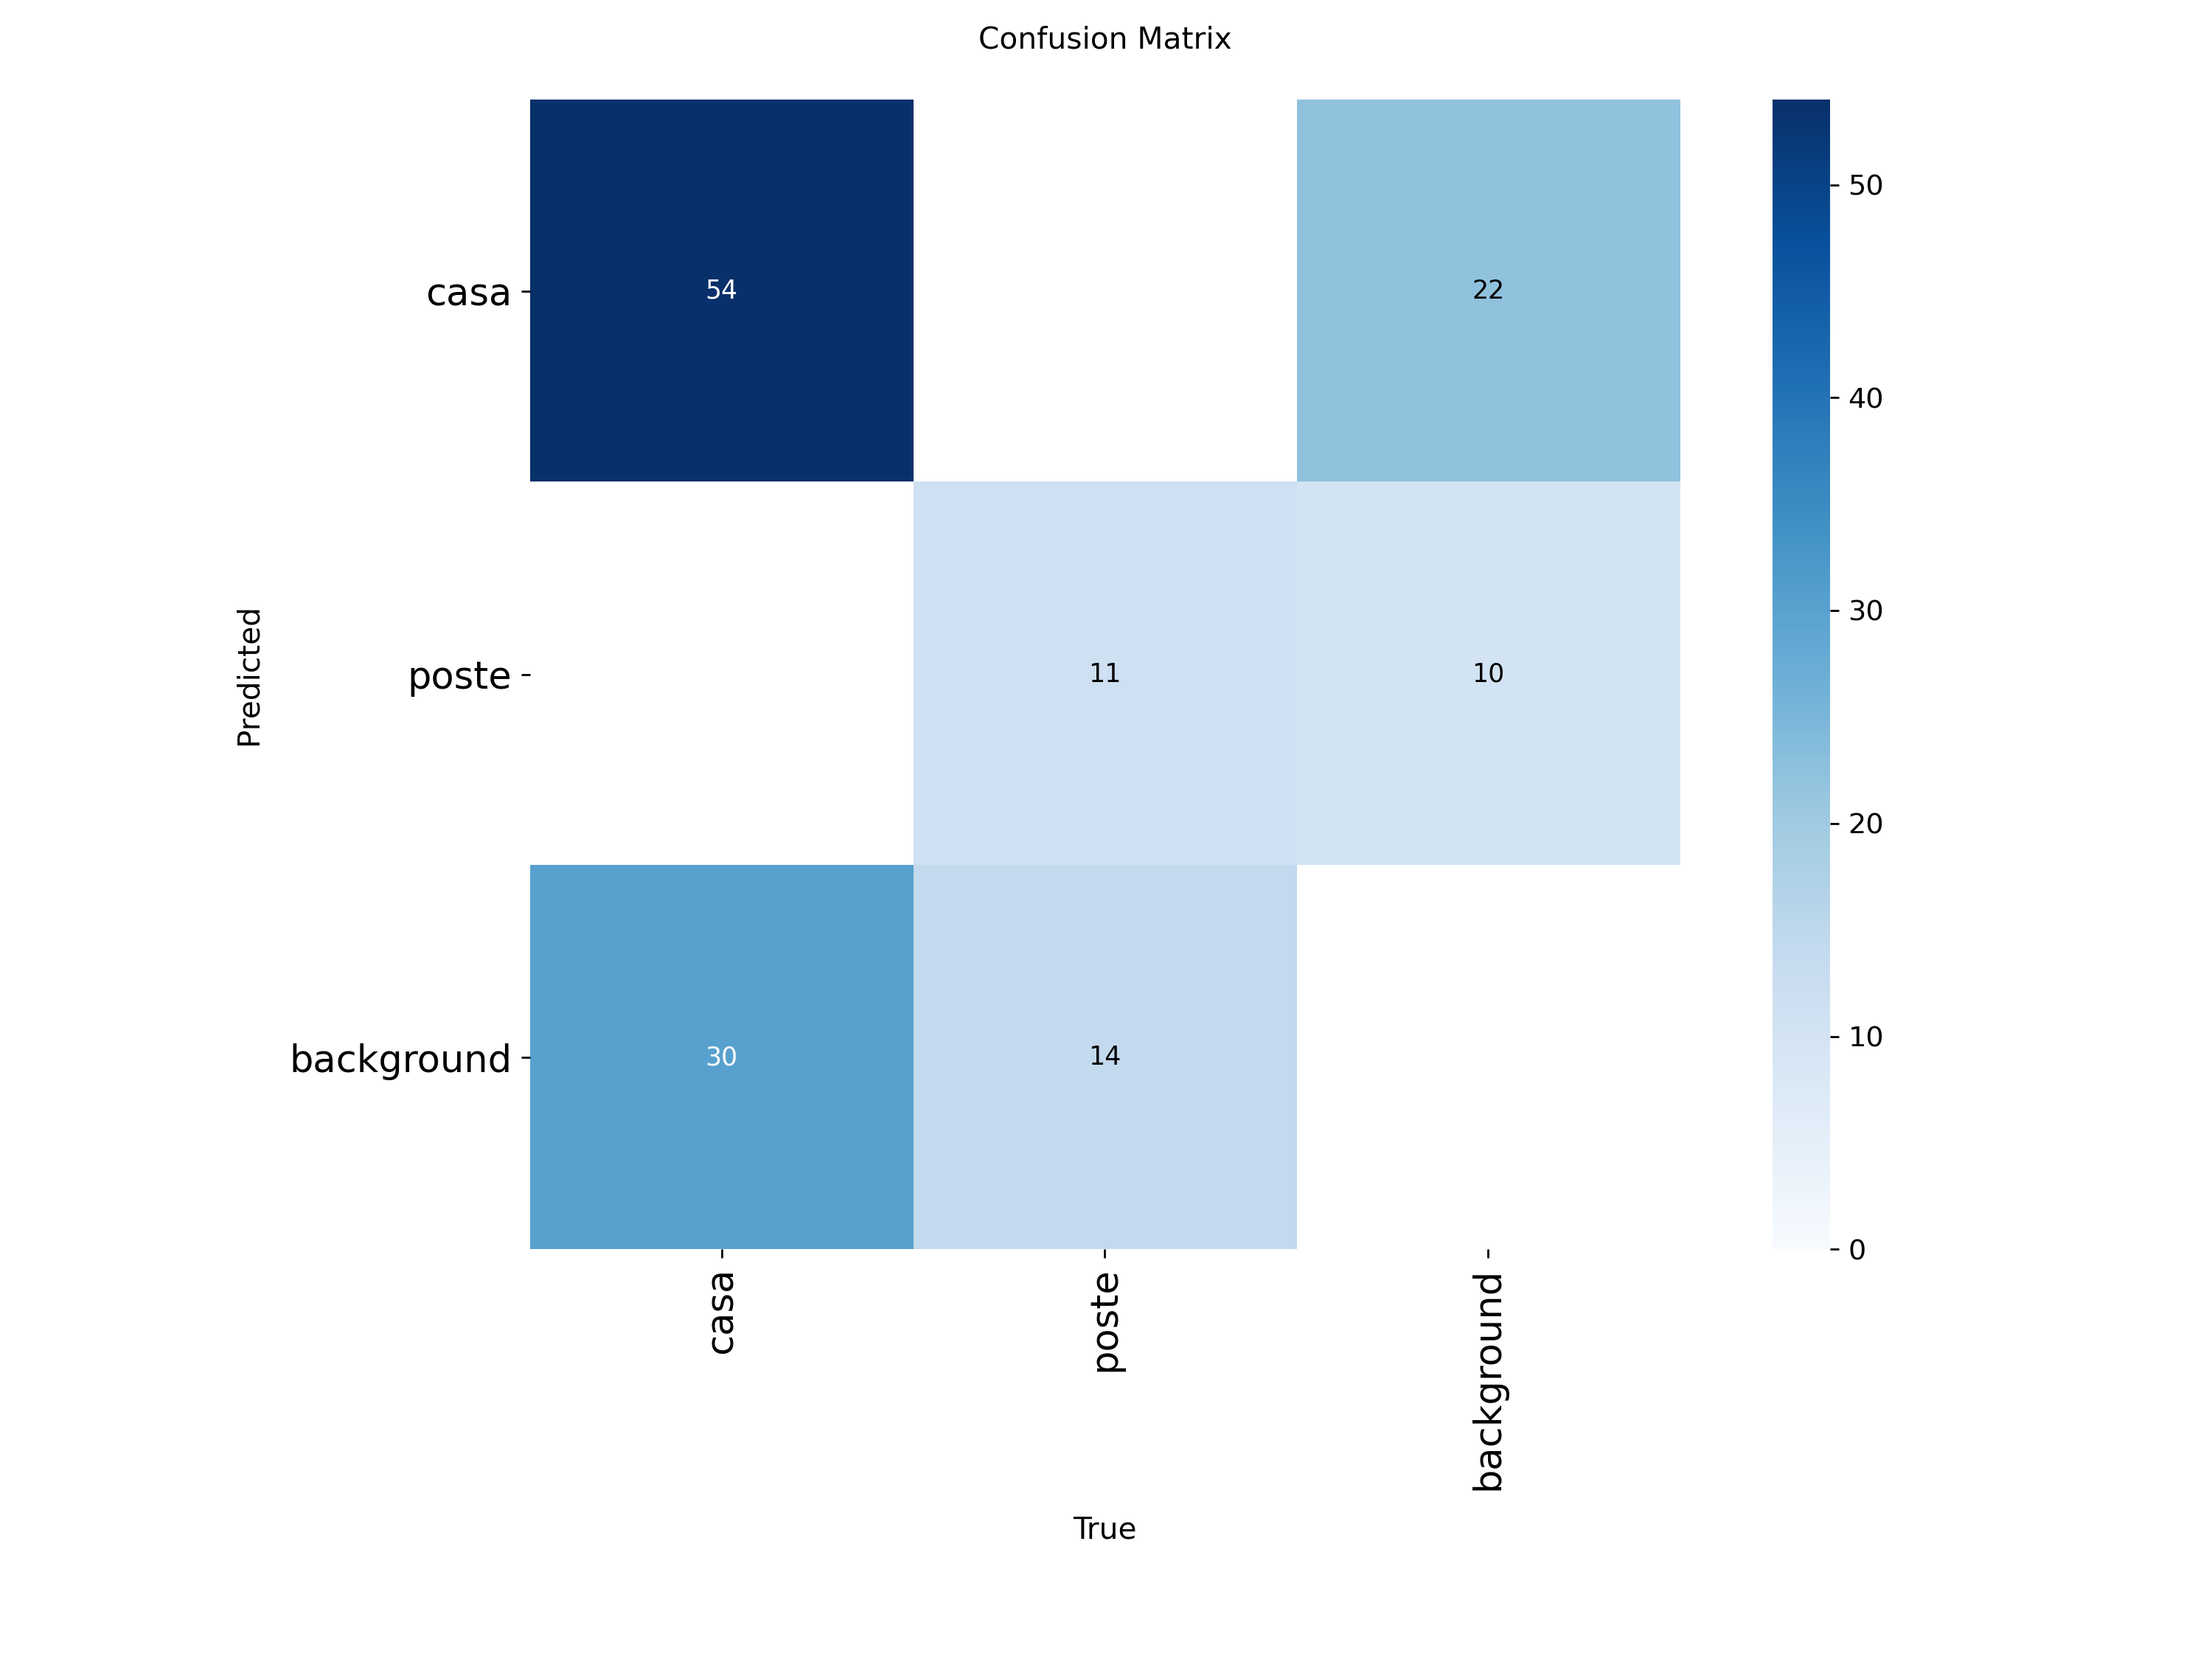

--- BoxP_curve.png ---


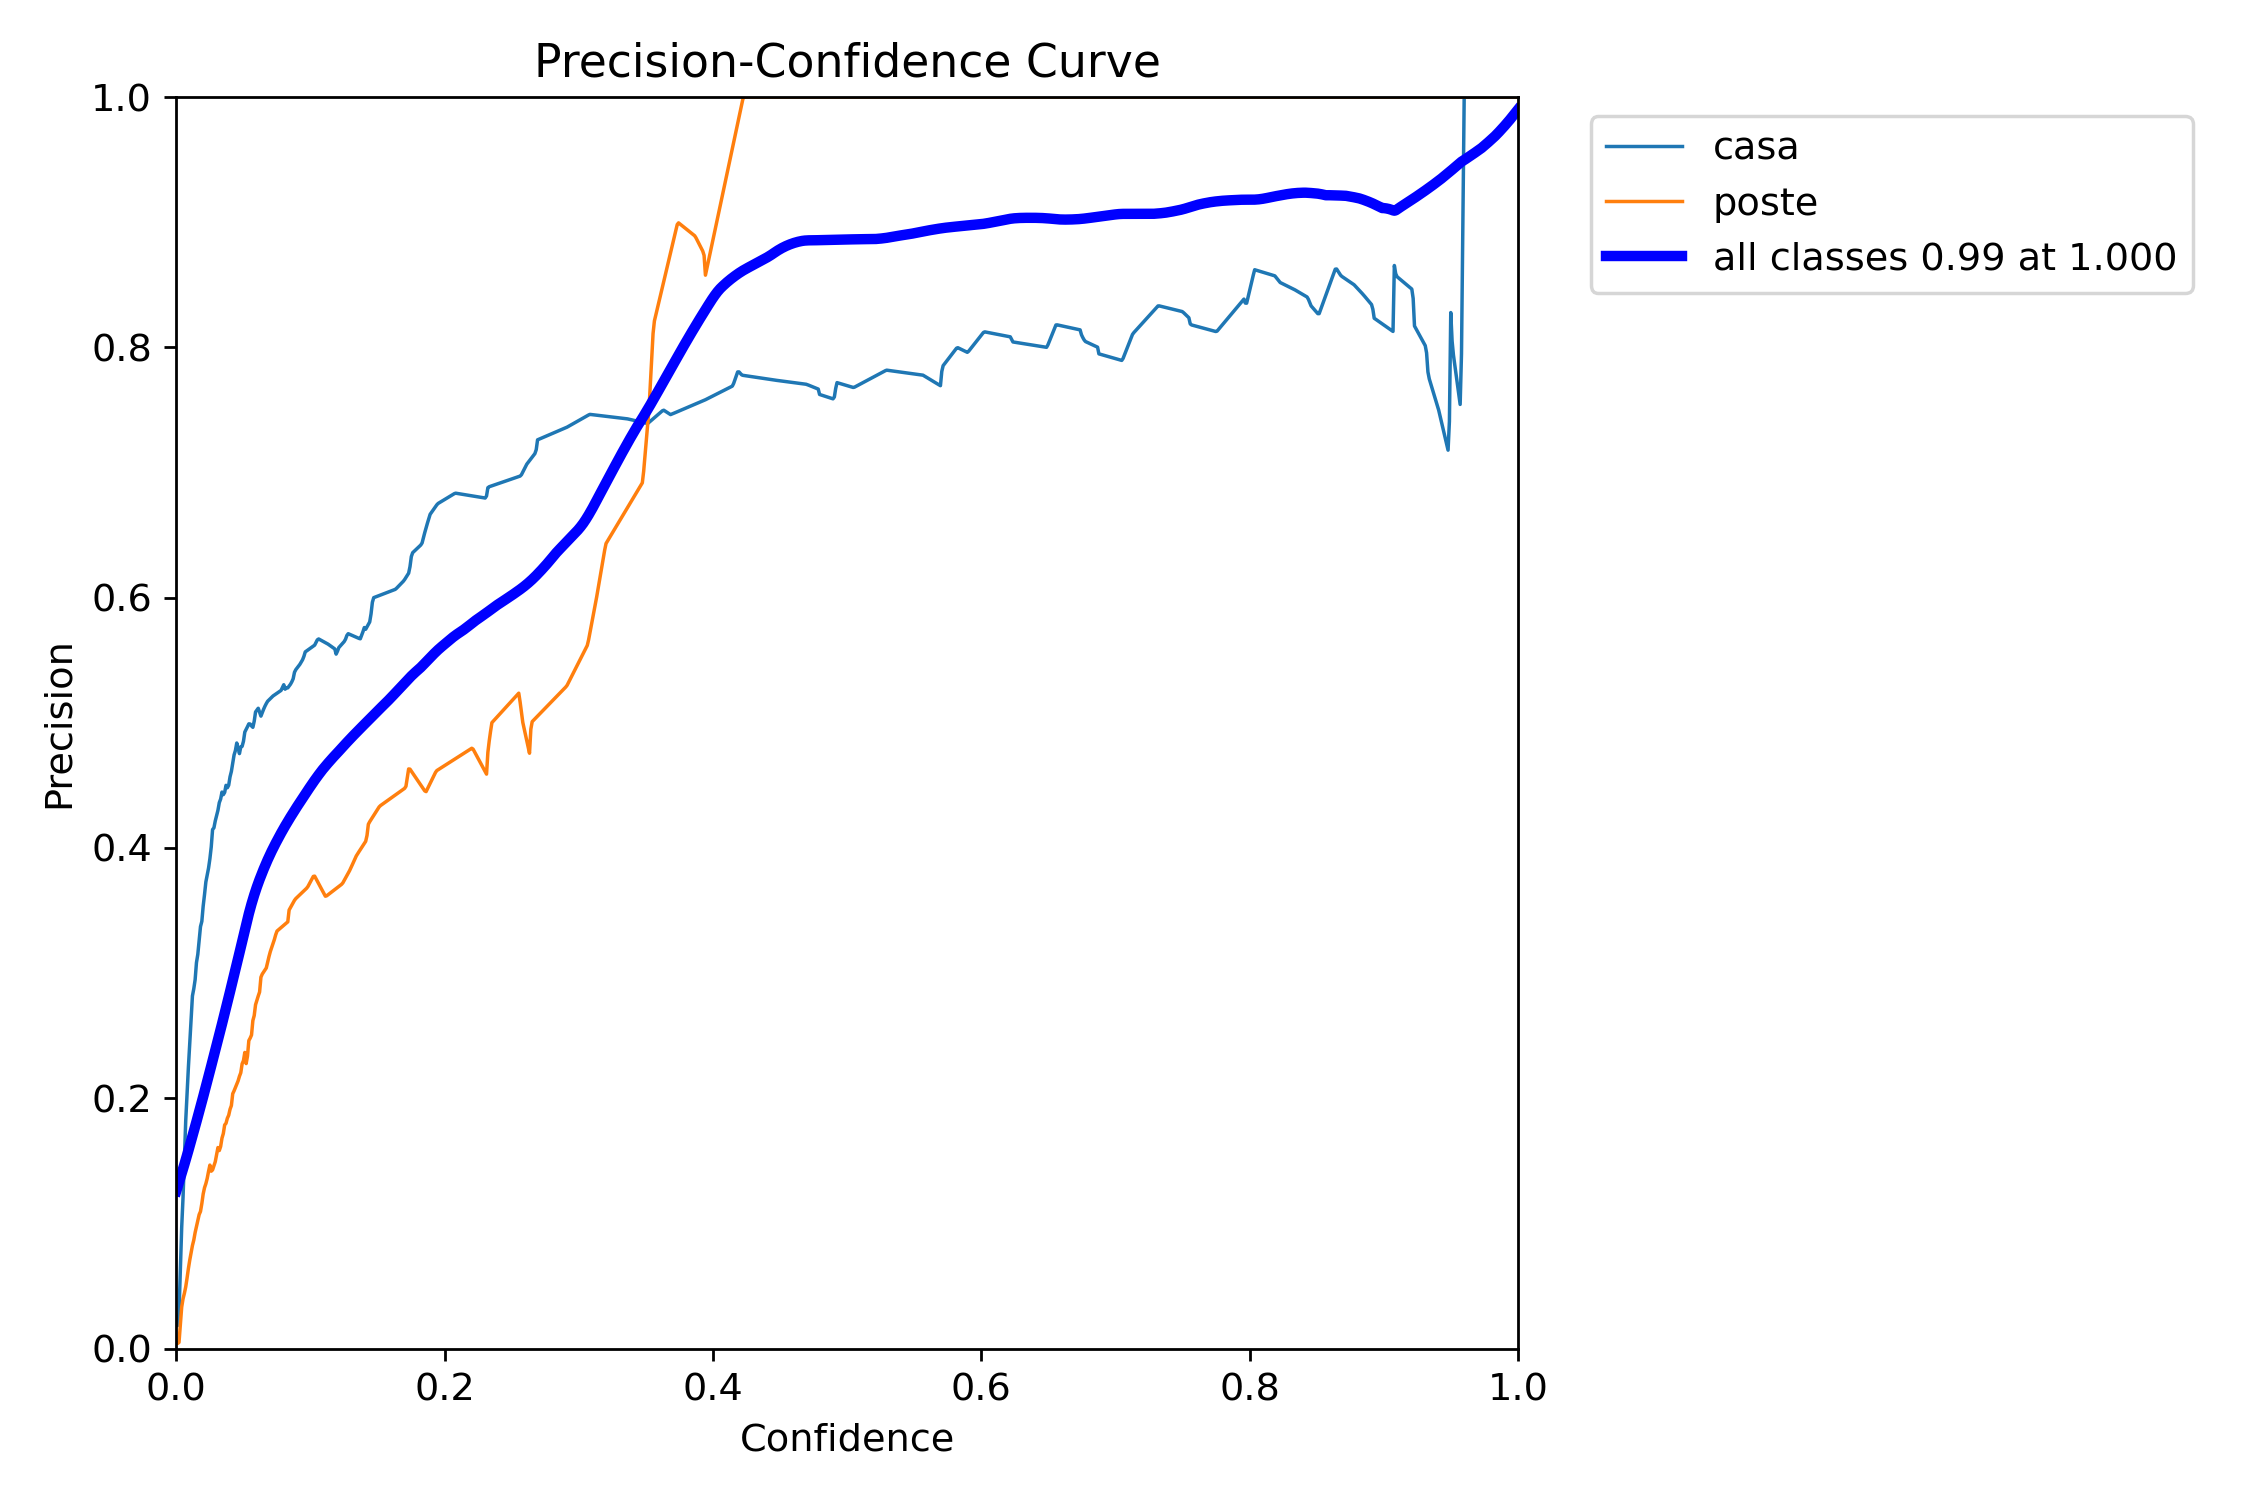

--- BoxR_curve.png ---


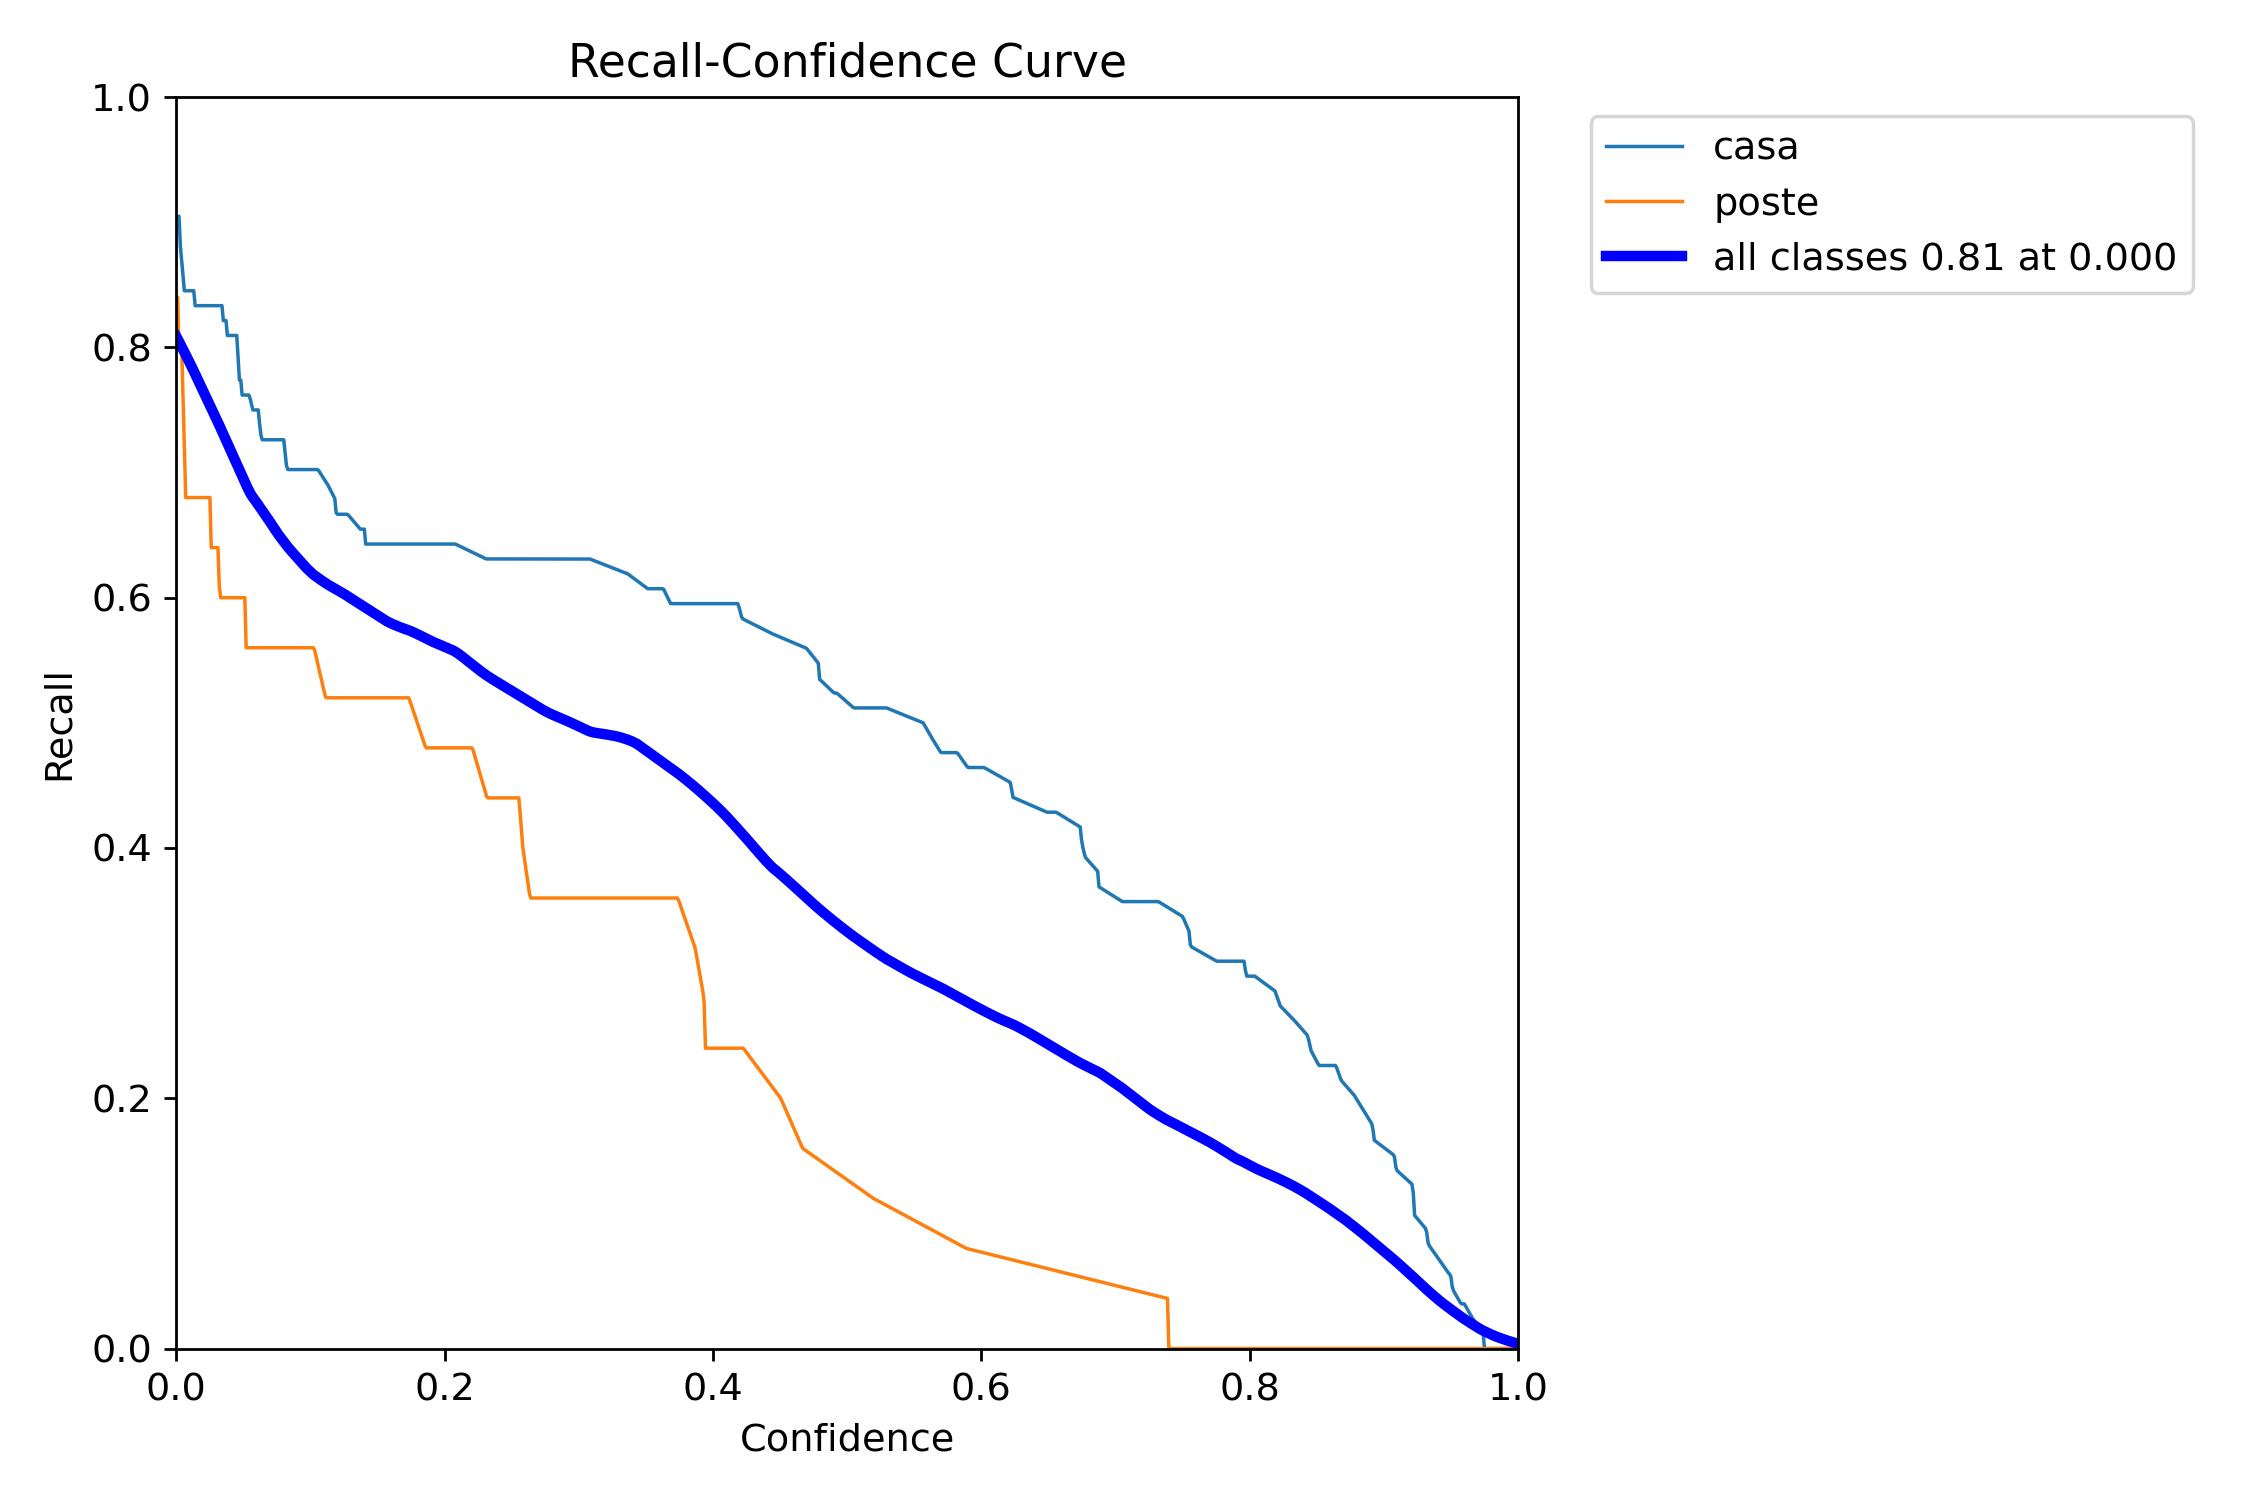

--- BoxF1_curve.png ---


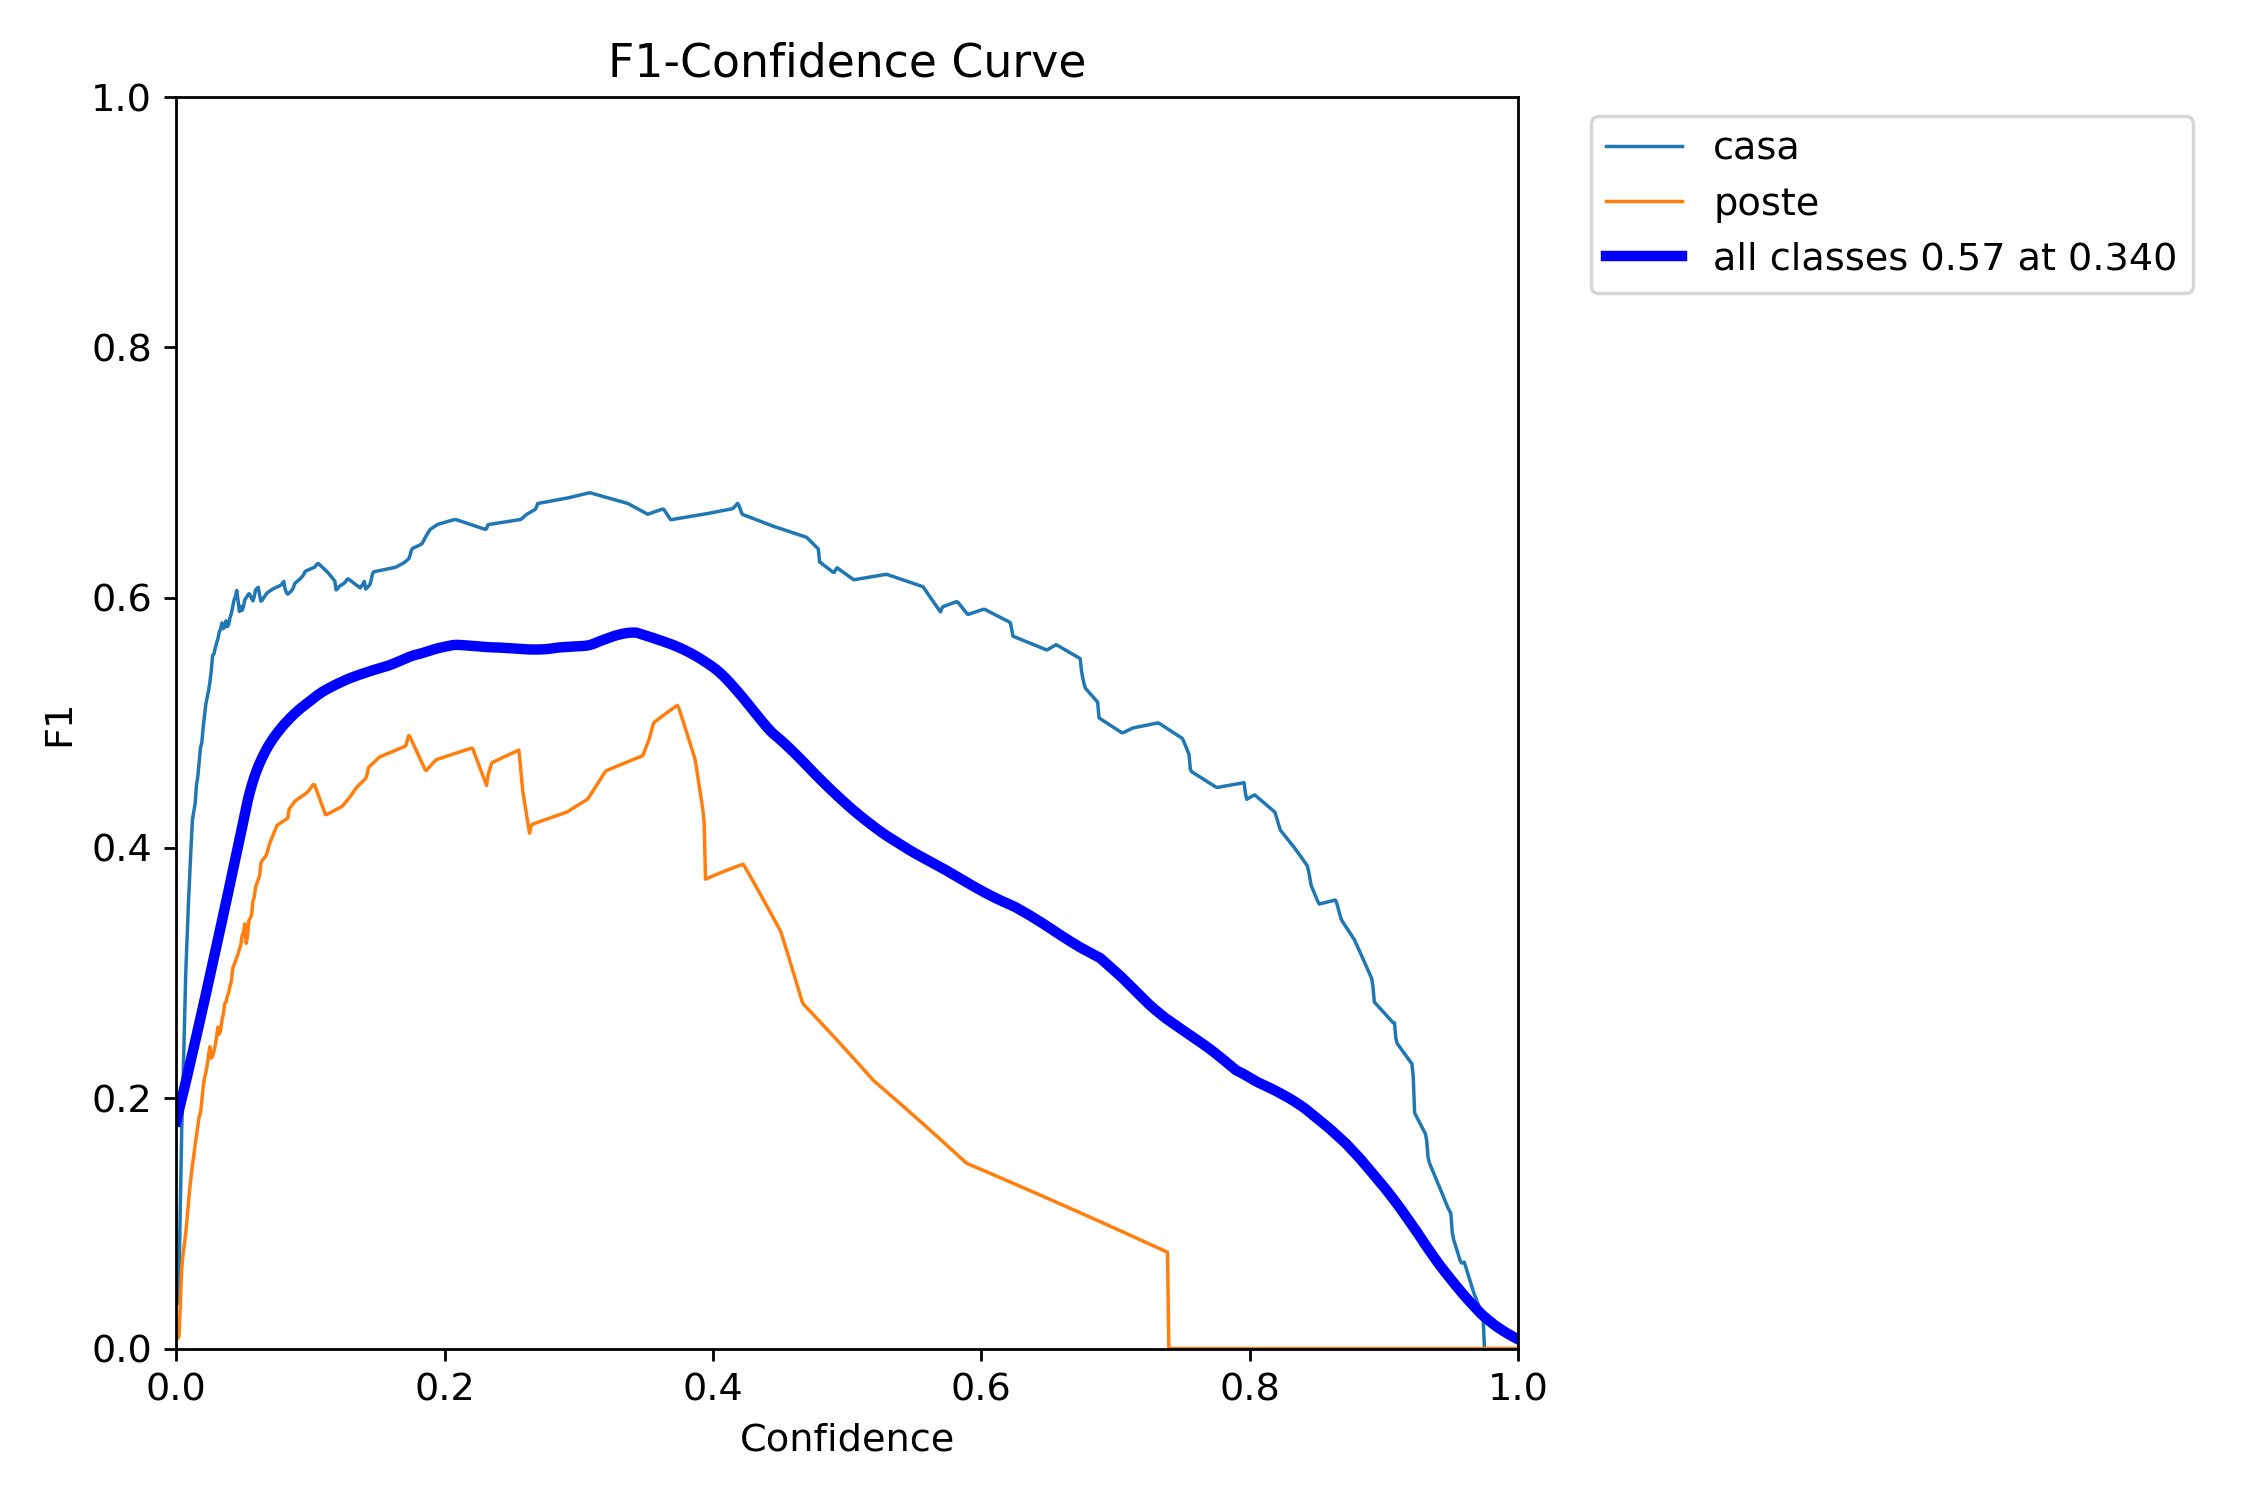

--- BoxPR_curve.png ---


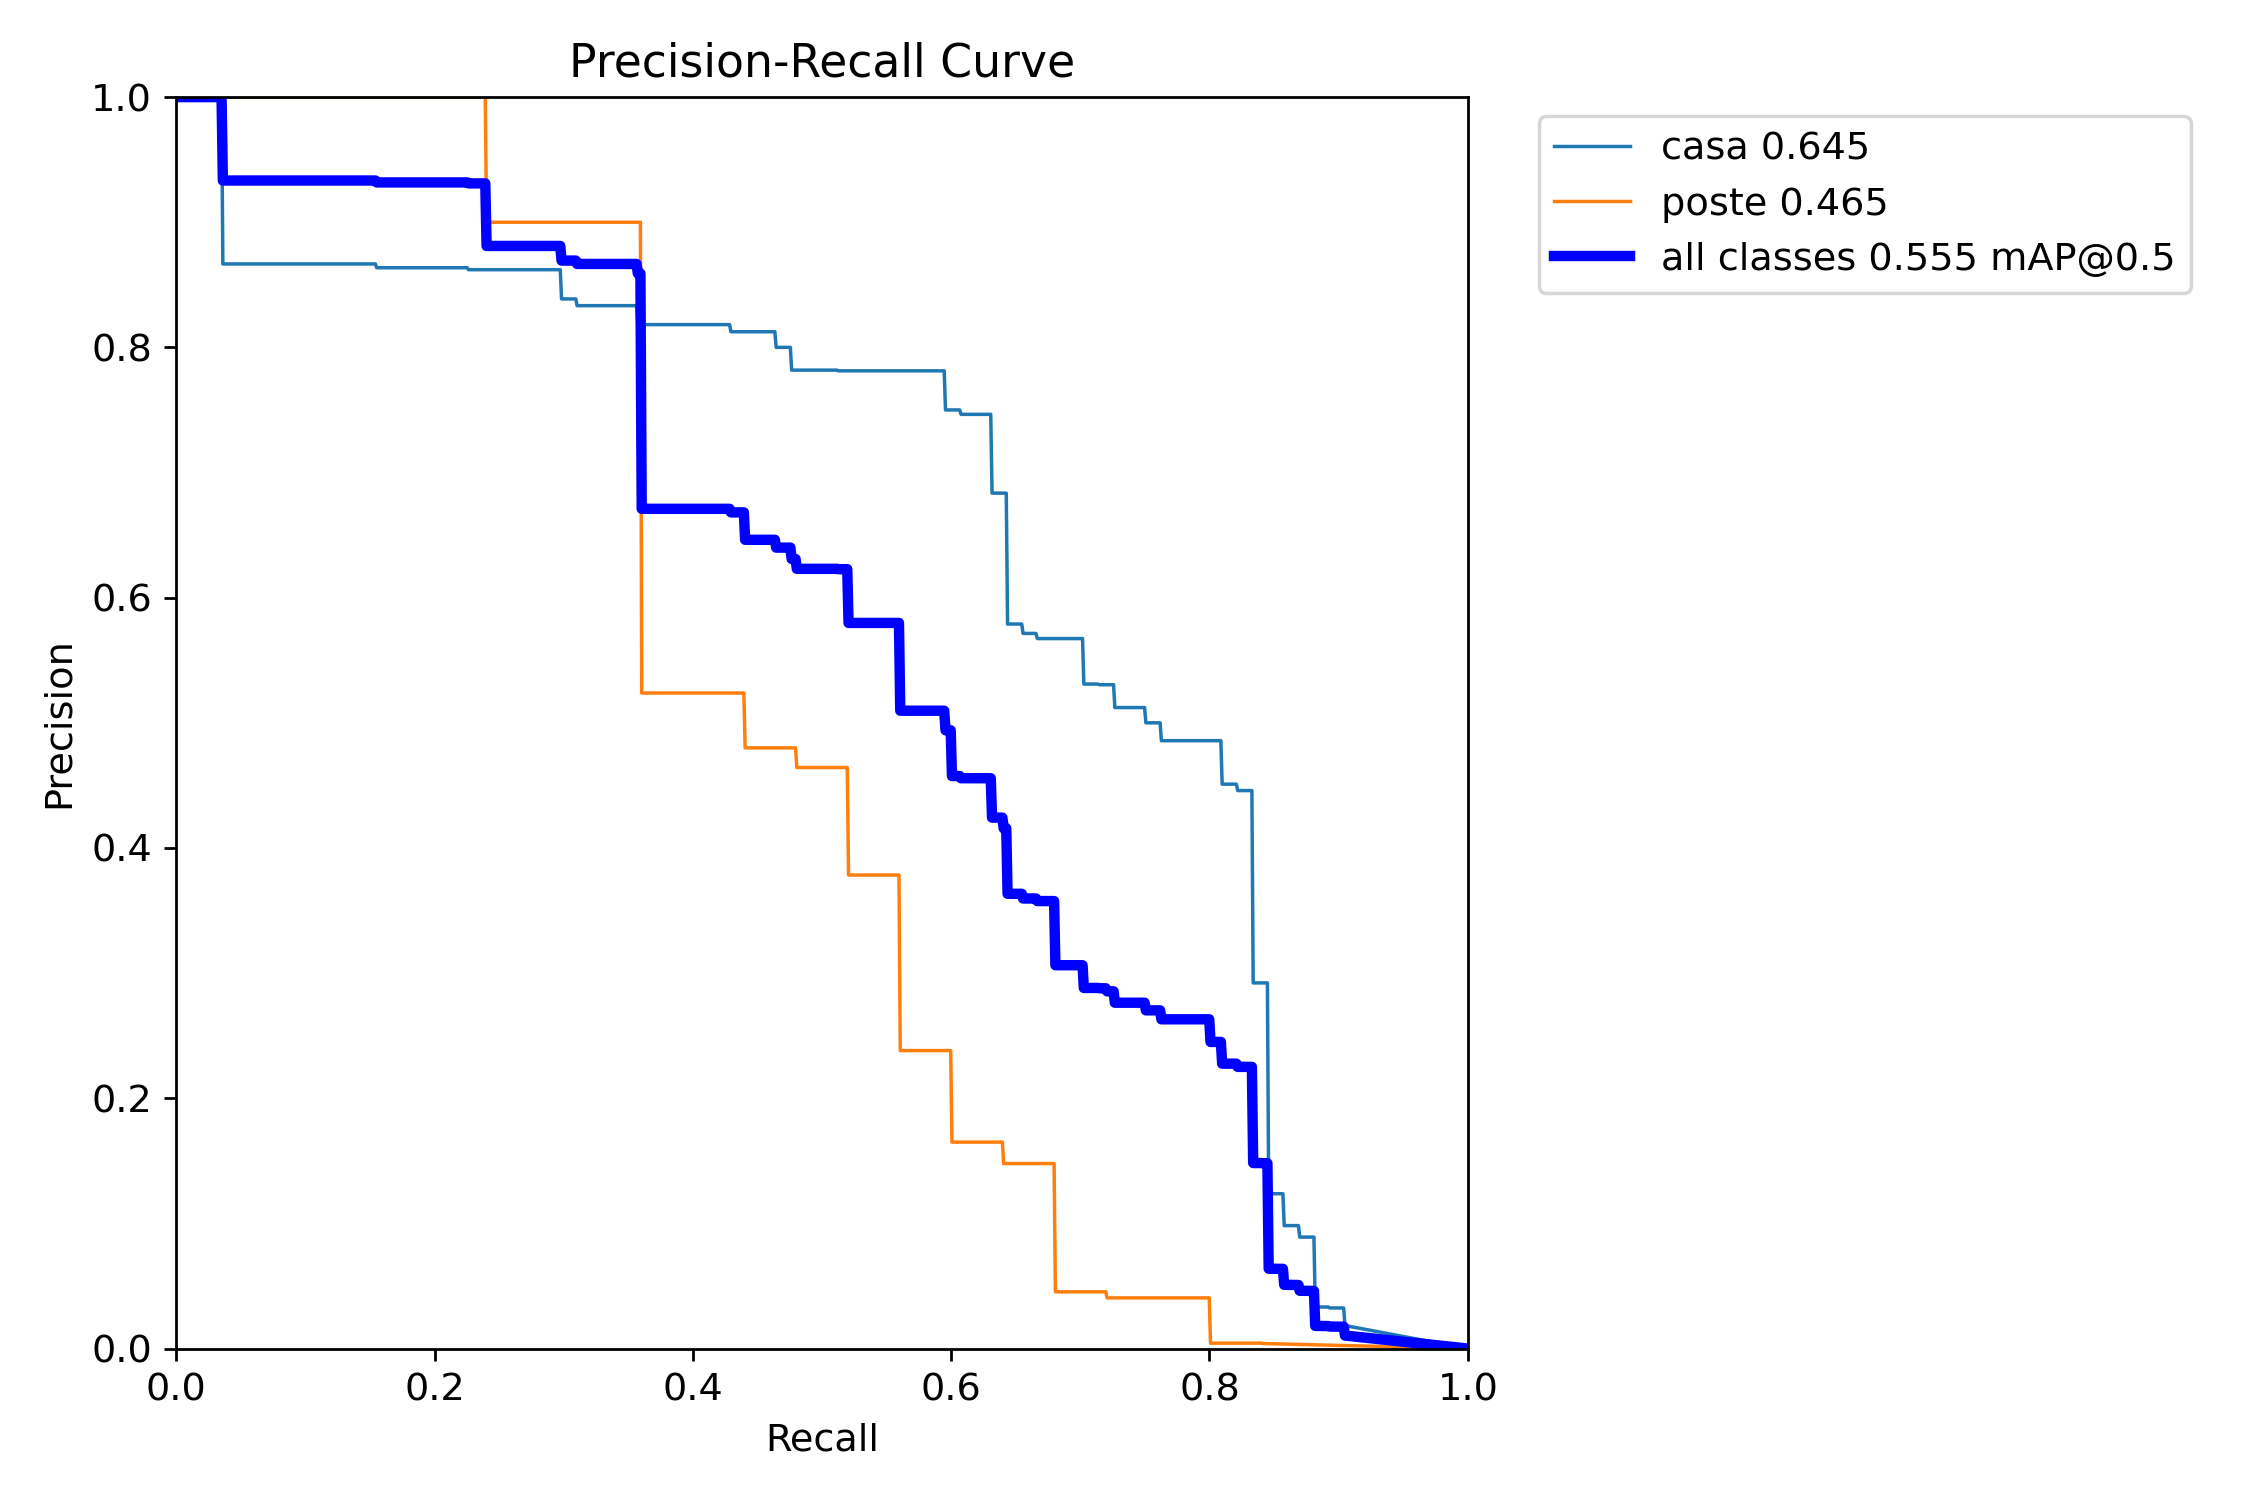

In [9]:
from IPython.display import Image as IPImage, display
import os

run_dir = os.path.join(PROJECT_DIR, RUN_NAME)

for plot in ['results.png', 'confusion_matrix.png',
             'BoxP_curve.png', 'BoxR_curve.png',
             'BoxF1_curve.png', 'BoxPR_curve.png']:
    p = os.path.join(run_dir, plot)
    if os.path.exists(p):
        print(f'--- {plot} ---')
        display(IPImage(p, width=800))

---
## 7. Evaluacion del modelo - mAP, Precision, Recall

In [10]:
from ultralytics import YOLO
import os

BEST_MODEL_PATH = os.path.join(PROJECT_DIR, RUN_NAME, 'weights', 'best.pt')

assert os.path.exists(BEST_MODEL_PATH), (
    f'No se encontro: {BEST_MODEL_PATH}\n'
    'Asegurate de que el entrenamiento (celda 5) termino correctamente.')

best_model = YOLO(BEST_MODEL_PATH)

print('=== Validacion - split VALID ===')
val_res = best_model.val(
    data   = DATA_YAML,
    split  = 'val',
    imgsz  = IMG_SIZE,
    device = 0,
    plots  = True,
)

print(f'  mAP@0.5      : {val_res.box.map50:.4f}')
print(f'  mAP@0.5:0.95 : {val_res.box.map:.4f}')
print(f'  Precision    : {val_res.box.mp:.4f}')
print(f'  Recall       : {val_res.box.mr:.4f}')

print('\n=== Metricas por clase ===')
for i, cls in enumerate(CLASSES):
    ap50 = val_res.box.ap50[i] if hasattr(val_res.box, 'ap50') else float('nan')
    ap   = val_res.box.ap[i]   if hasattr(val_res.box, 'ap')   else float('nan')
    print(f'  [{cls}]  AP@0.5={ap50:.4f}  AP@0.5:0.95={ap:.4f}')

=== Validacion - split VALID ===
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 56.8±28.9 MB/s, size: 109.5 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/valid/labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 14.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4it/s 1.5s
                   all         31        109      0.701       0.49       0.56      0.336
                  casa         31         84      0.743      0.619      0.647      0.434
                 poste         11         25       0.66       0.36      0.473      0.238
Speed: 4.9ms preprocess, 13.1ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/v

In [11]:
print('=== Evaluacion - split TEST ===')
test_res = best_model.val(
    data   = DATA_YAML,
    split  = 'test',
    imgsz  = IMG_SIZE,
    device = 0,
    plots  = False,
)
print(f'  mAP@0.5      : {test_res.box.map50:.4f}')
print(f'  mAP@0.5:0.95 : {test_res.box.map:.4f}')
print(f'  Precision    : {test_res.box.mp:.4f}')
print(f'  Recall       : {test_res.box.mr:.4f}')

=== Evaluacion - split TEST ===
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.7±0.2 ms, read: 0.1±0.0 MB/s, size: 135.2 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/test/labels... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 1.5s/it 28.4s
val: New cache created: /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.9it/s 0.5s
                   all         19         62      0.638      0.586      0.626      0.373
                  casa         19         46      0.655      0.661      0.696      0.472
                 poste         11         16       0.62      0.511      0.555      0.274
Speed: 0.7ms preprocess, 7.3ms inference, 0.0ms loss, 2.4ms postprocess per

---
## 8. Inferencia con visualizacion de predicciones

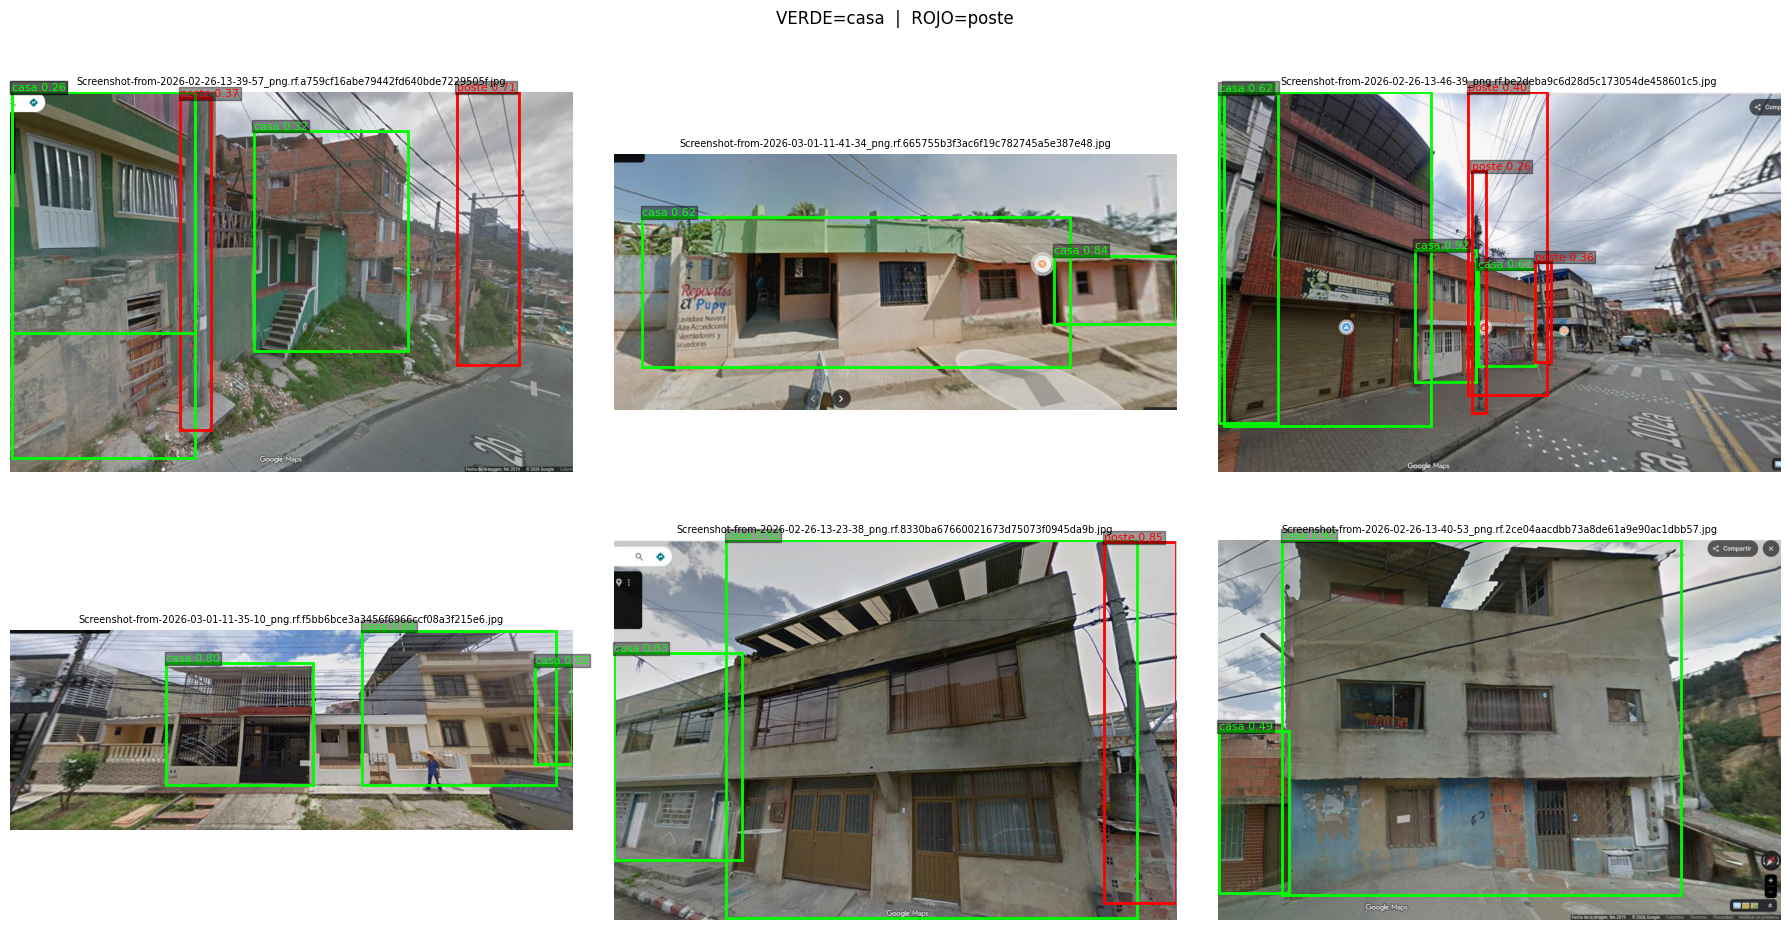

Guardado en /content/predicciones_muestra.png


In [12]:
import os, random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

best_model = YOLO(BEST_MODEL_PATH)

test_images_dir = os.path.join(DATASET_PATH, 'test', 'images')
all_imgs = [os.path.join(test_images_dir, f)
            for f in os.listdir(test_images_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

sample = random.sample(all_imgs, min(6, len(all_imgs)))
COLOR  = {0: 'lime', 1: 'red'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample):
    preds = best_model.predict(img_path, conf=0.25, verbose=False)[0]
    ax.imshow(Image.open(img_path).convert('RGB'))
    for box in preds.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cid   = int(box.cls[0])
        conf  = float(box.conf[0])
        color = COLOR.get(cid, 'yellow')
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1, linewidth=2,
            edgecolor=color, facecolor='none'))
        ax.text(x1, y1-4, f"{CLASSES[cid]} {conf:.2f}",
                color=color, fontsize=8,
                bbox=dict(facecolor='black', alpha=0.4, pad=1))
    ax.set_title(os.path.basename(img_path), fontsize=7)
    ax.axis('off')

for ax in axes[len(sample):]:
    ax.axis('off')

plt.suptitle('VERDE=casa  |  ROJO=poste', fontsize=12)
plt.tight_layout()
plt.savefig('/content/predicciones_muestra.png', dpi=120)
plt.show()
print('Guardado en /content/predicciones_muestra.png')

---
## 9. Generacion de mascaras de postes detectados

Para cada imagen de test se crea una mascara PNG binaria:
- **Blanco (255)** = region del poste (bbox)
- **Negro (0)** = fondo

Estas mascaras son la entrada para los modelos de inpainting.

In [13]:
import os
import numpy as np
from PIL import Image
from ultralytics import YOLO

best_model = YOLO(BEST_MODEL_PATH)

test_images_dir = os.path.join(DATASET_PATH, 'test', 'images')
test_imgs = [os.path.join(test_images_dir, f)
             for f in os.listdir(test_images_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f'Procesando {len(test_imgs)} imagenes...')
generated, skipped = 0, 0

for img_path in test_imgs:
    stem  = os.path.splitext(os.path.basename(img_path))[0]
    preds = best_model.predict(img_path, conf=0.25, verbose=False)[0]
    W, H  = Image.open(img_path).size
    mask  = np.zeros((H, W), dtype=np.uint8)

    found = False
    for box in preds.boxes:
        if int(box.cls[0]) == CLASS_POSTE_ID:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(W, x2), min(H, y2)
            mask[y1:y2, x1:x2] = 255
            found = True

    if found:
        Image.fromarray(mask).save(os.path.join(MASKS_DIR, f'{stem}_mask.png'))
        generated += 1
    else:
        skipped += 1

print(f'Mascaras generadas : {generated}')
print(f'Sin postes         : {skipped}')
print(f'Total              : {len(test_imgs)}')

Procesando 19 imagenes...
Mascaras generadas : 8
Sin postes         : 11
Total              : 19


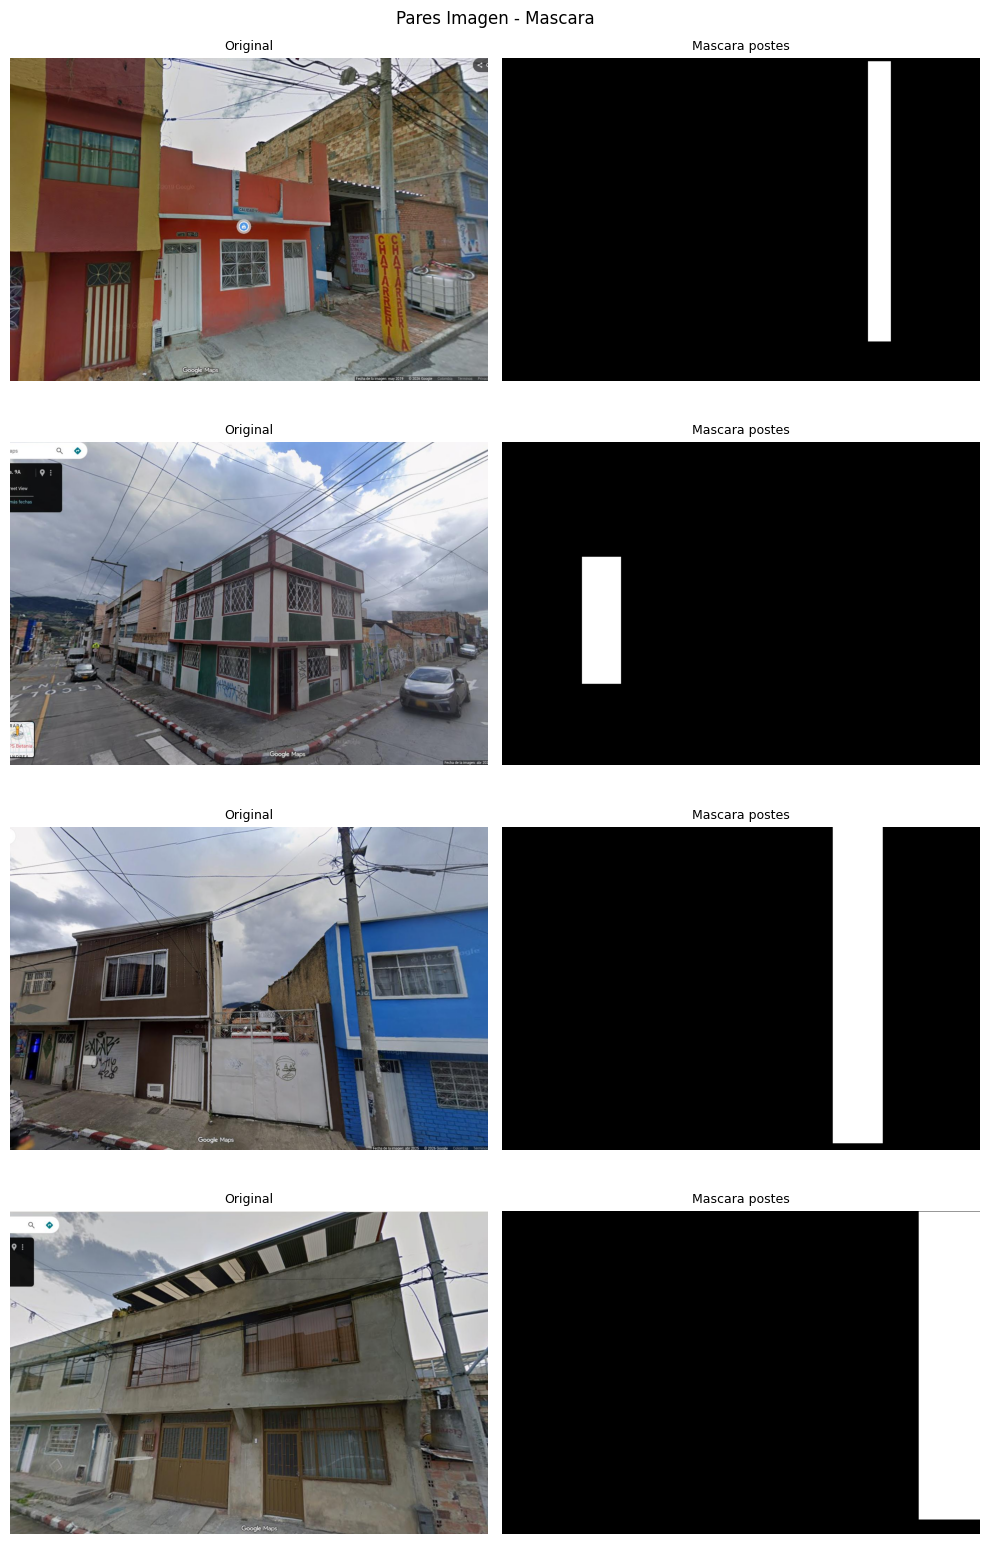

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import os

mask_files = sorted([f for f in os.listdir(MASKS_DIR) if f.endswith('_mask.png')])[:4]

if not mask_files:
    print('No se generaron mascaras (no se detectaron postes en test).')
else:
    fig, axes = plt.subplots(len(mask_files), 2, figsize=(10, 4 * len(mask_files)))
    if len(mask_files) == 1:
        axes = [axes]

    for row, mf in enumerate(mask_files):
        stem     = mf.replace('_mask.png', '')
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            c = os.path.join(test_images_dir, stem + ext)
            if os.path.exists(c):
                img_path = c
                break

        mask_img = Image.open(os.path.join(MASKS_DIR, mf))

        if img_path:
            axes[row][0].imshow(Image.open(img_path))
        axes[row][0].set_title('Original', fontsize=9)
        axes[row][0].axis('off')

        axes[row][1].imshow(mask_img, cmap='gray')
        axes[row][1].set_title('Mascara postes', fontsize=9)
        axes[row][1].axis('off')

    plt.suptitle('Pares Imagen - Mascara', fontsize=12)
    plt.tight_layout()
    plt.savefig('/content/pares_imagen_mascara.png', dpi=120)
    plt.show()

---
## 10A. Inpainting con LaMa

Repositorio: https://github.com/advimman/lama

**Descomenta todo el bloque** para usarlo.

In [ ]:
# OPCION A: LaMa
# Descomenta todo el bloque para usar este modelo de inpainting.

!git clone https://github.com/advimman/lama.git /content/lama
%cd /content/lama
!pip install -r requirements.txt

!curl -L 'https://huggingface.co/smartywu/big-lama/resolve/main/big-lama.zip' \\ -o /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/lama/big-lama.zip
!unzip -q /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/lama/big-lama.zip -d /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/lama/lama_models

import shutil, os
from PIL import Image as PILImage
LAMA_IN  = '/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/lama_input';  os.makedirs(LAMA_IN, exist_ok=True)
LAMA_OUT = '/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/lama_output'; os.makedirs(LAMA_OUT, exist_ok=True)

for mf in os.listdir(MASKS_DIR):
    if not mf.endswith('_mask.png'):
        continue
    stem = mf.replace('_mask.png', '')
    for ext in ['.jpg', '.jpeg', '.png']:
        src = os.path.join(test_images_dir, stem + ext)
        if os.path.exists(src):
            PILImage.open(src).convert('RGB').save(os.path.join(LAMA_IN, stem + '.png'))
            break
    shutil.copy(os.path.join(MASKS_DIR, mf), os.path.join(LAMA_IN, mf))

%cd /content/lama
!python bin/predict.py \\ model.path=/content/lama_models/big-lama \\ indir=/content/lama_input \\ outdir=/content/lama_output \\ dataset.img_suffix=.png

print('Resultados en /content/lama_output')

print('Opcion A (LaMa) comentada. Descomenta el bloque para usarla.')

fatal: destination path '/content/lama' already exists and is not an empty directory.
/content/lama
  Using cached easydict-1.9.tar.gz (6.4 kB)
  Preparing metadata (setup.py) ... done
  Using cached scikit-image-0.17.2.tar.gz (29.8 MB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1383  100  1383    0     0   7271      0 --:--:-- --:--:-- --:--:--  7278
100  363M  100  363M    0     0  44.3M   

---
## 10B. Inpainting con Inpaint-Anything

Repositorio: https://github.com/geekyutao/Inpaint-Anything

Combina SAM + LaMa o Stable Diffusion.

**Descomenta todo el bloque** para usarlo.

In [15]:
# OPCION B: Inpaint-Anything
# Descomenta todo el bloque para usar este modelo de inpainting.

!git clone https://github.com/geekyutao/Inpaint-Anything.git /content/Inpaint-Anything
%cd /content/Inpaint-Anything
!pip install -r requirements.txt

!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth \\-O /content/sam_vit_h.pth

!curl -L 'https://huggingface.co/smartywu/big-lama/resolve/main/big-lama.zip' \\-o /content/big-lama.zip
!unzip -q /content/big-lama.zip -d /content/lama_models

import os
IA_OUT = '/content/inpaint_output'
os.makedirs(IA_OUT, exist_ok=True)
for mf in os.listdir(MASKS_DIR):
    if not mf.endswith('_mask.png'):
        continue
    stem = mf.replace('_mask.png', '')
    img_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        c = os.path.join(test_images_dir, stem + ext)
        if os.path.exists(c):
            img_path = c
            break
    if not img_path:
        continue
    mask_path = os.path.join(MASKS_DIR, mf)
    !python /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/Inpaint-Anything/remove_anything.py \\ --input_img  "{img_path}" \\ --input_mask "{mask_path}" \\ --lama_config /content/Inpaint-Anything/lama/configs/prediction/default.yaml \\ --lama_ckpt  /content/lama_models/big-lama \\ --output_dir "{IA_OUT}"

# print('Resultados en /content/inpaint_output')

print('Opcion B (Inpaint-Anything) comentada. Descomenta el bloque para usarla.')

Cloning into '/content/Inpaint-Anything'...
remote: Enumerating objects: 2090, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 2090 (delta 105), reused 80 (delta 80), pack-reused 1929 (from 2)
Receiving objects: 100% (2090/2090), 330.75 MiB | 16.82 MiB/s, done.
Resolving deltas: 100% (658/658), done.
Updating files: 100% (712/712), done.
/content/Inpaint-Anything
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
^C
unzip:  cannot find or open /content/big-lama.zip, /content/big-lama.zip.zip or /content/big-lama.zip.ZIP.
python3: can't open file '/content/drive/MyDrive/Colab': [Errno 2] No such file or directory
python3: can't open file '/content/drive/MyDrive/Colab': [Errno 2] No such file or directory
python3: can't open file '/content/drive/MyDrive/Colab': [Errno 2] No such file or directory
python3: can't open file '/content/drive/MyDrive/Colab': [Errno 2] No such file

In [16]:
# ===== 10B FINAL SIMPLE (OpenCV Inpainting) =====

import os
import cv2
import numpy as np

# ⚠️ ASEGÚRATE de que estas rutas existan
# (ajústalas si ya las tienes definidas)
MASKS_DIR = '/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/mascaras_postes'
test_images_dir = '/content/drive/MyDrive/Colab Notebooks/Applied/Taller2/dataset_roboflow_t3/casas.yolov8/test'

OUT_DIR = '/content/inpaint_output'
os.makedirs(OUT_DIR, exist_ok=True)

for mf in os.listdir(MASKS_DIR):

    if not mf.endswith('_mask.png'):
        continue

    stem = mf.replace('_mask.png', '')

    # buscar imagen original
    img_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        c = os.path.join(test_images_dir, stem + ext)
        if os.path.exists(c):
            img_path = c
            break

    if not img_path:
        continue

    mask_path = os.path.join(MASKS_DIR, mf)

    # cargar imagen y máscara
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, 0)

    # 🔥 mejorar máscara (clave)
    kernel = np.ones((7,7), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=2)

    # 🎯 INPAINTING (OpenCV)
    result = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)

    # guardar resultado
    out_path = os.path.join(OUT_DIR, f'{stem}_inpaint.png')
    cv2.imwrite(out_path, result)

print("✅ Inpainting terminado con OpenCV")

✅ Inpainting terminado con OpenCV


In [22]:
# ===== 10B FINAL COMPLETO (ROBUSTO + DRIVE) =====

import os
import cv2
import numpy as np

# ===== 🔧 RUTAS (AJUSTADAS A TU CASO) =====

DRIVE_ROOT = '/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2'

MASKS_DIR = os.path.join(DRIVE_ROOT, "mascaras_postes")

test_images_dir = "/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/dataset_roboflow_t3/casas.yolov8/test/images"

OUT_DIR = os.path.join(DRIVE_ROOT, "resultados_inpainting")
os.makedirs(OUT_DIR, exist_ok=True)

# ===== 🧪 DEBUG INICIAL =====
print("Mascaras encontradas:", len(os.listdir(MASKS_DIR)))
print("Imagenes encontradas:", len(os.listdir(test_images_dir)))

# ===== 🔁 LOOP PRINCIPAL =====
procesadas = 0
no_encontradas = 0

for mf in os.listdir(MASKS_DIR):

    if not mf.endswith('_mask.png'):
        continue

    stem = mf.replace('_mask.png', '')

    # 🔥 MATCH ROBUSTO (ignora mayúsculas/minúsculas)
    img_path = None
    for f in os.listdir(test_images_dir):
        name = os.path.splitext(f)[0]

        if name.lower() == stem.lower():
            img_path = os.path.join(test_images_dir, f)
            break

    if not img_path:
        print(f"❌ No encontrada: {stem}")
        no_encontradas += 1
        continue

    mask_path = os.path.join(MASKS_DIR, mf)

    # ===== 📥 CARGAR =====
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, 0)

    if img is None or mask is None:
        print(f"⚠️ Error leyendo: {stem}")
        continue

    # ===== 🔥 MEJORAR MÁSCARA =====
    kernel = np.ones((7,7), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=2)

    # ===== 🎯 INPAINTING =====
    result = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)

    # ===== 💾 GUARDAR =====
    out_path = os.path.join(OUT_DIR, f"{stem}_inpaint.png")
    cv2.imwrite(out_path, result)

    print(f"✅ Procesada: {stem}")
    procesadas += 1

# ===== 📊 RESUMEN =====
print("\n===== RESUMEN =====")
print(f"Procesadas     : {procesadas}")
print(f"No encontradas : {no_encontradas}")
print(f"Resultados en  : {OUT_DIR}")

Mascaras encontradas: 9
Imagenes encontradas: 19
✅ Procesada: Screenshot-from-2026-02-26-13-23-38_png.rf.8330ba67660021673d75073f0945da9b
✅ Procesada: Screenshot-from-2026-02-26-13-22-03_png.rf.9875111bc85a6a032e24168dd42bbe85
✅ Procesada: Screenshot-from-2026-02-26-13-46-39_png.rf.be2deba9c6d28d5c173054de458601c5
✅ Procesada: Screenshot-from-2026-02-26-13-20-33_png.rf.0b4bd316d587b3a0dbd9d2160de8c04f
✅ Procesada: Screenshot-from-2026-02-26-13-38-41_png.rf.06a678e4b77d037953e71b22e1c8af60
✅ Procesada: Screenshot-from-2026-03-01-11-53-35_png.rf.a272e1f4e596a96cd3a042fd9dd95c3a
✅ Procesada: Screenshot-from-2026-03-01-11-35-10_png.rf.f5bb6bce3a3456f6966ccf08a3f215e6
✅ Procesada: Screenshot-from-2026-02-26-13-39-57_png.rf.a759cf16abe79442fd640bde7229505f
✅ Procesada: Screenshot-from-2026-02-26-13-22-14_png.rf.cd85e00825f94760a90bbda6ad74457d

===== RESUMEN =====
Procesadas     : 9
No encontradas : 0
Resultados en  : /content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/resultados_

---
## 11. Visualizar resultados del inpainting

Ajusta OUTPUT_DIR segun la opcion elegida:
- LaMa: /content/lama_output
- Inpaint-Anything: /content/inpaint_output

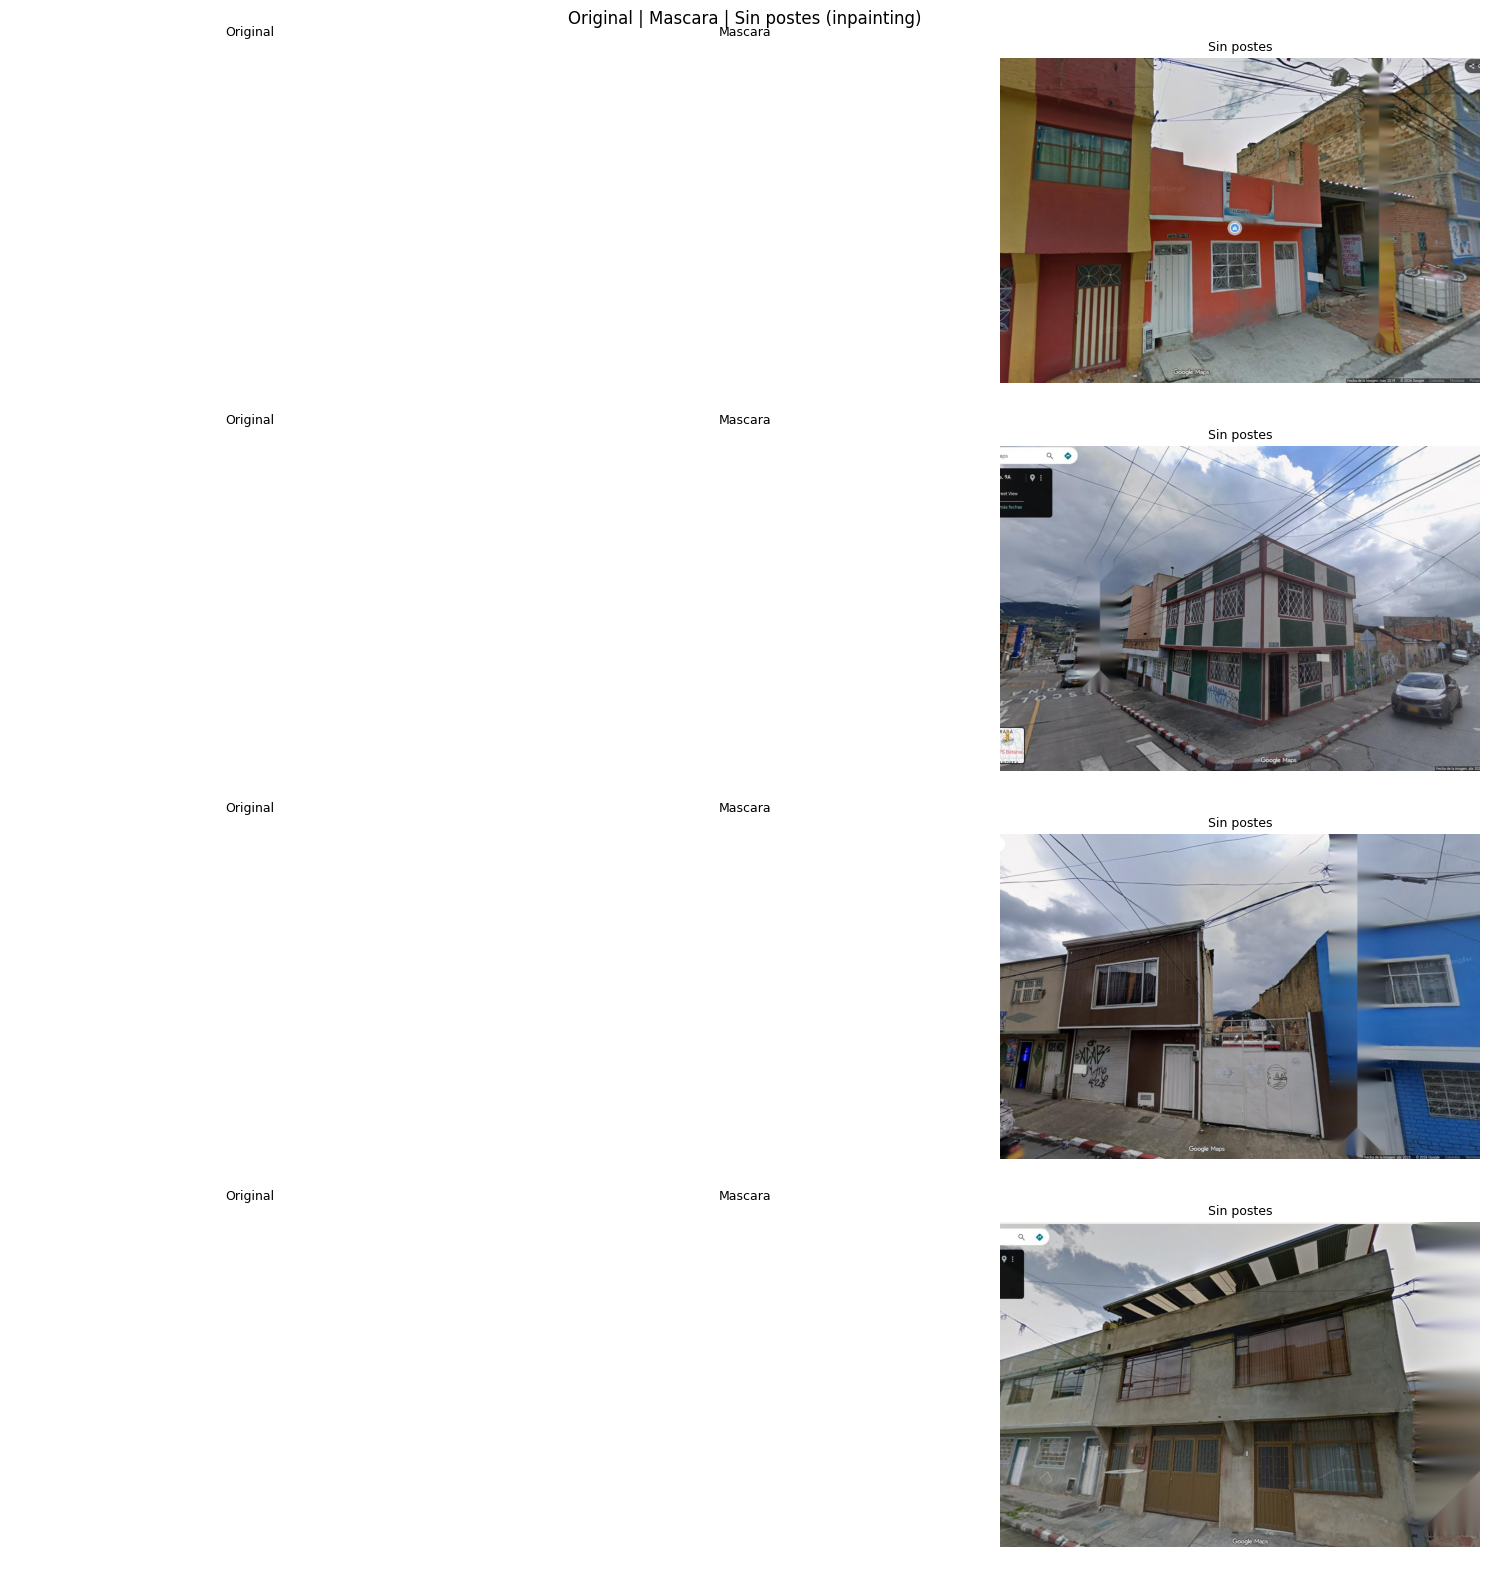

Guardado en /content/comparativa_inpainting.png


In [23]:
import os
import matplotlib.pyplot as plt
from PIL import Image

OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/resultados_inpainting'  # cambia a /content/inpaint_output si usaste opcion B

if not os.path.exists(OUTPUT_DIR) or not os.listdir(OUTPUT_DIR):
    print(f'Directorio vacio o inexistente: {OUTPUT_DIR}')
    print('Ejecuta primero la celda 10A o 10B.')
else:
    out_imgs = sorted([os.path.join(OUTPUT_DIR, f)
                       for f in os.listdir(OUTPUT_DIR)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])[:4]

    fig, axes = plt.subplots(len(out_imgs), 3, figsize=(15, 4 * len(out_imgs)))
    if len(out_imgs) == 1:
        axes = [axes]

    for row, out_path in enumerate(out_imgs):
        stem      = os.path.splitext(os.path.basename(out_path))[0]
        orig_stem = stem.replace('_inpainted', '')

        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            c = os.path.join(test_images_dir, orig_stem + ext)
            if os.path.exists(c):
                img_path = c
                break
        mask_path = os.path.join(MASKS_DIR, orig_stem + '_mask.png')

        if img_path:
            axes[row][0].imshow(Image.open(img_path))
        axes[row][0].set_title('Original', fontsize=9)
        axes[row][0].axis('off')

        if os.path.exists(mask_path):
            axes[row][1].imshow(Image.open(mask_path), cmap='gray')
        axes[row][1].set_title('Mascara', fontsize=9)
        axes[row][1].axis('off')

        axes[row][2].imshow(Image.open(out_path))
        axes[row][2].set_title('Sin postes', fontsize=9)
        axes[row][2].axis('off')

    plt.suptitle('Original | Mascara | Sin postes (inpainting)', fontsize=12)
    plt.tight_layout()
    plt.savefig('/content/comparativa_inpainting.png', dpi=120)
    plt.show()
    print('Guardado en /content/comparativa_inpainting.png')

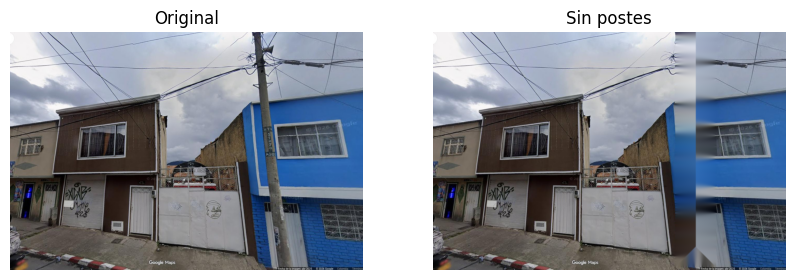

In [24]:
import matplotlib.pyplot as plt
import cv2
import os

stem = "Screenshot-from-2026-02-26-13-22-14_png.rf.cd85e00825f94760a90bbda6ad74457d"

img_path = os.path.join(test_images_dir, stem + ".jpg")  # o .png según tengas
res_path = os.path.join(OUT_DIR, stem + "_inpaint.png")

img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
res = cv2.cvtColor(cv2.imread(res_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(res)
plt.title("Sin postes")
plt.axis('off')

plt.show()

---
## 12. Exportar modelo y descargar artefactos

In [25]:
from ultralytics import YOLO
best_model = YOLO(BEST_MODEL_PATH)
best_model.export(format='onnx')
print('ONNX exportado en:', BEST_MODEL_PATH.replace('.pt', '.onnx'))

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Colab Notebooks/Aplicaciones ML/Taller2/casas_postes_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 208ms
Prepared 4 packages in 3.71s
Installed 4 packages in 421ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 5.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: start

In [26]:
from google.colab import files
files.download(BEST_MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import shutil
zip_path = '/content/mascaras_postes'
shutil.make_archive(zip_path, 'zip', MASKS_DIR)
from google.colab import files
files.download(zip_path + '.zip')
print('ZIP de mascaras descargado.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ZIP de mascaras descargado.


---
## Resumen del pipeline

| # | Paso | Descripcion |
|---|------|-------------|
| 0 | Config | Rutas y parametros globales (DRIVE_ROOT automatico) |
| 1 | GPU | Verificacion de acelerador |
| 2 | Deps | Instalacion de ultralytics, OpenCV, PIL |
| 3 | Drive | Montaje y verificacion del dataset |
| 4 | YAML | Preparacion de data.yaml con rutas absolutas |
| 5 | Train | Fine-tuning YOLOv8 - 2 clases: casa, poste |
| 6 | Plots | Curvas de entrenamiento |
| 7 | Eval | mAP@0.5, mAP@0.5:0.95, Precision, Recall |
| 8 | Infer | Inferencia con bounding boxes coloreados |
| 9 | Mascaras | Generacion de mascaras binarias de postes |
| 10A/B | Inpainting | LaMa o Inpaint-Anything (a eleccion) |
| 11 | Viz | Comparativa Original / Mascara / Sin postes |
| 12 | Export | ONNX + descarga de artefactos |

**Clases**: 0 = casa  /  1 = poste